### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [4]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, utils, optimizers, preprocessing

In [6]:
from imblearn.over_sampling import RandomOverSampler

### Step 2: Constant

In [7]:
MAX_WORDS = 5000
MAX_LEN = 100

### Step 3: Load Data

In [8]:
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\bhr\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
df = pd.read_csv('./data/Dataset---Hate-Speech-Detection-using-Deep-Learning.csv')

In [10]:
df.shape

(24783, 2)

In [11]:
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


### Step 4: Exploaring Data

#### Basic Info

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   24783 non-null  int64 
 1   tweet   24783 non-null  object
dtypes: int64(1), object(1)
memory usage: 387.4+ KB


In [13]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100 * df.isnull().sum()/len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [14]:
feature_info

,null,null(%),unique,type
class,0,0.0,3,int64
tweet,0,0.0,24783,object


#### Target Distribution

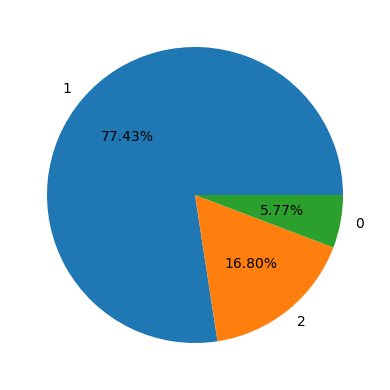

In [15]:
temp = df['class'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index
)
plt.tight_layout()

### Step 5: Feature Engineering

#### String Lower

In [16]:
df['tweet'] = df['tweet'].str.lower()

#### Punctuations Removal

In [17]:
punctuations_list = string.punctuation

In [18]:
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

In [19]:
df['tweet']= df['tweet'].apply(lambda x: remove_punctuations(x))

#### Stopwords Removal and Lemmatization

In [20]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

In [21]:
df['tweet'] = df['tweet'].apply(preprocess_text)

#### Plot Word Cloud

In [22]:
typ_list = ['Hate Speech', 'Offensive Language', 'Neither']

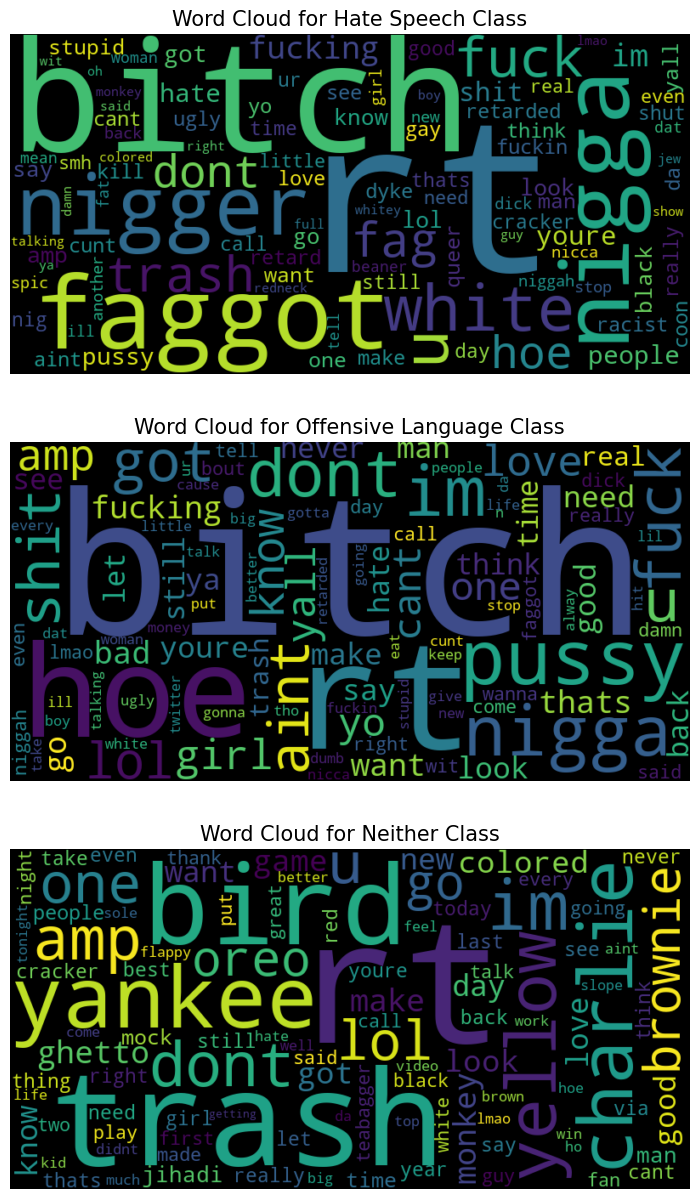

In [23]:
plt.figure(figsize=(10, 15))
for i in range(3):
    temp = df[df['class']==i]
    corpus = " ".join(temp['tweet'])
    wc = WordCloud(
        max_words=100, 
        width=800, 
        height=400,
        collocations=False
    ).generate(corpus)
    plt.subplot(3, 1, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {typ_list[i]} Class", fontsize=15)

#### Split Data

In [24]:
features = df.drop('class', axis=1)
target = df['class']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.2, 
    random_state=42
)

#### Balance Data

In [26]:
ros = RandomOverSampler(
    sampling_strategy='minority', 
    random_state=42
)

In [27]:
X_train, y_train = ros.fit_resample(X_train, y_train)

#### Tokenization and Padding

In [28]:
tokenizer = preprocessing.text.Tokenizer(num_words=MAX_WORDS, lower=True, split=' ')

In [29]:
tokenizer.fit_on_texts(X_train['tweet'])

In [30]:
X_train = tokenizer.texts_to_sequences(X_train['tweet'])
X_test = tokenizer.texts_to_sequences(X_test['tweet'])

In [31]:
X_train = preprocessing.sequence.pad_sequences(
    X_train, 
    maxlen=MAX_LEN, 
    padding='post', 
    truncating='post'
)
X_test = preprocessing.sequence.pad_sequences(
    X_test,
    maxlen=MAX_LEN, 
    padding='post', 
    truncating='post'
)

### Step 6: Model Development

#### Build Model

In [96]:
inputs = layers.Input(shape=(MAX_LEN,))
x = layers.Embedding(input_dim=MAX_WORDS, output_dim=32, input_length=MAX_LEN)(inputs)
x = layers.Bidirectional(layers.LSTM(128, dropout=0.5))(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x)

In [97]:
model = Model(inputs, outputs)

In [98]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_9 (Embedding)              │ (None, 100, 32)             │         160,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_6 (Bidirectional)      │ (None, 256)                 │         164,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 591,619 (2.26 MB)

 Trainable params: 590,083 (2.25 MB)

 Non-trainable params: 1,536 (6.00 KB)

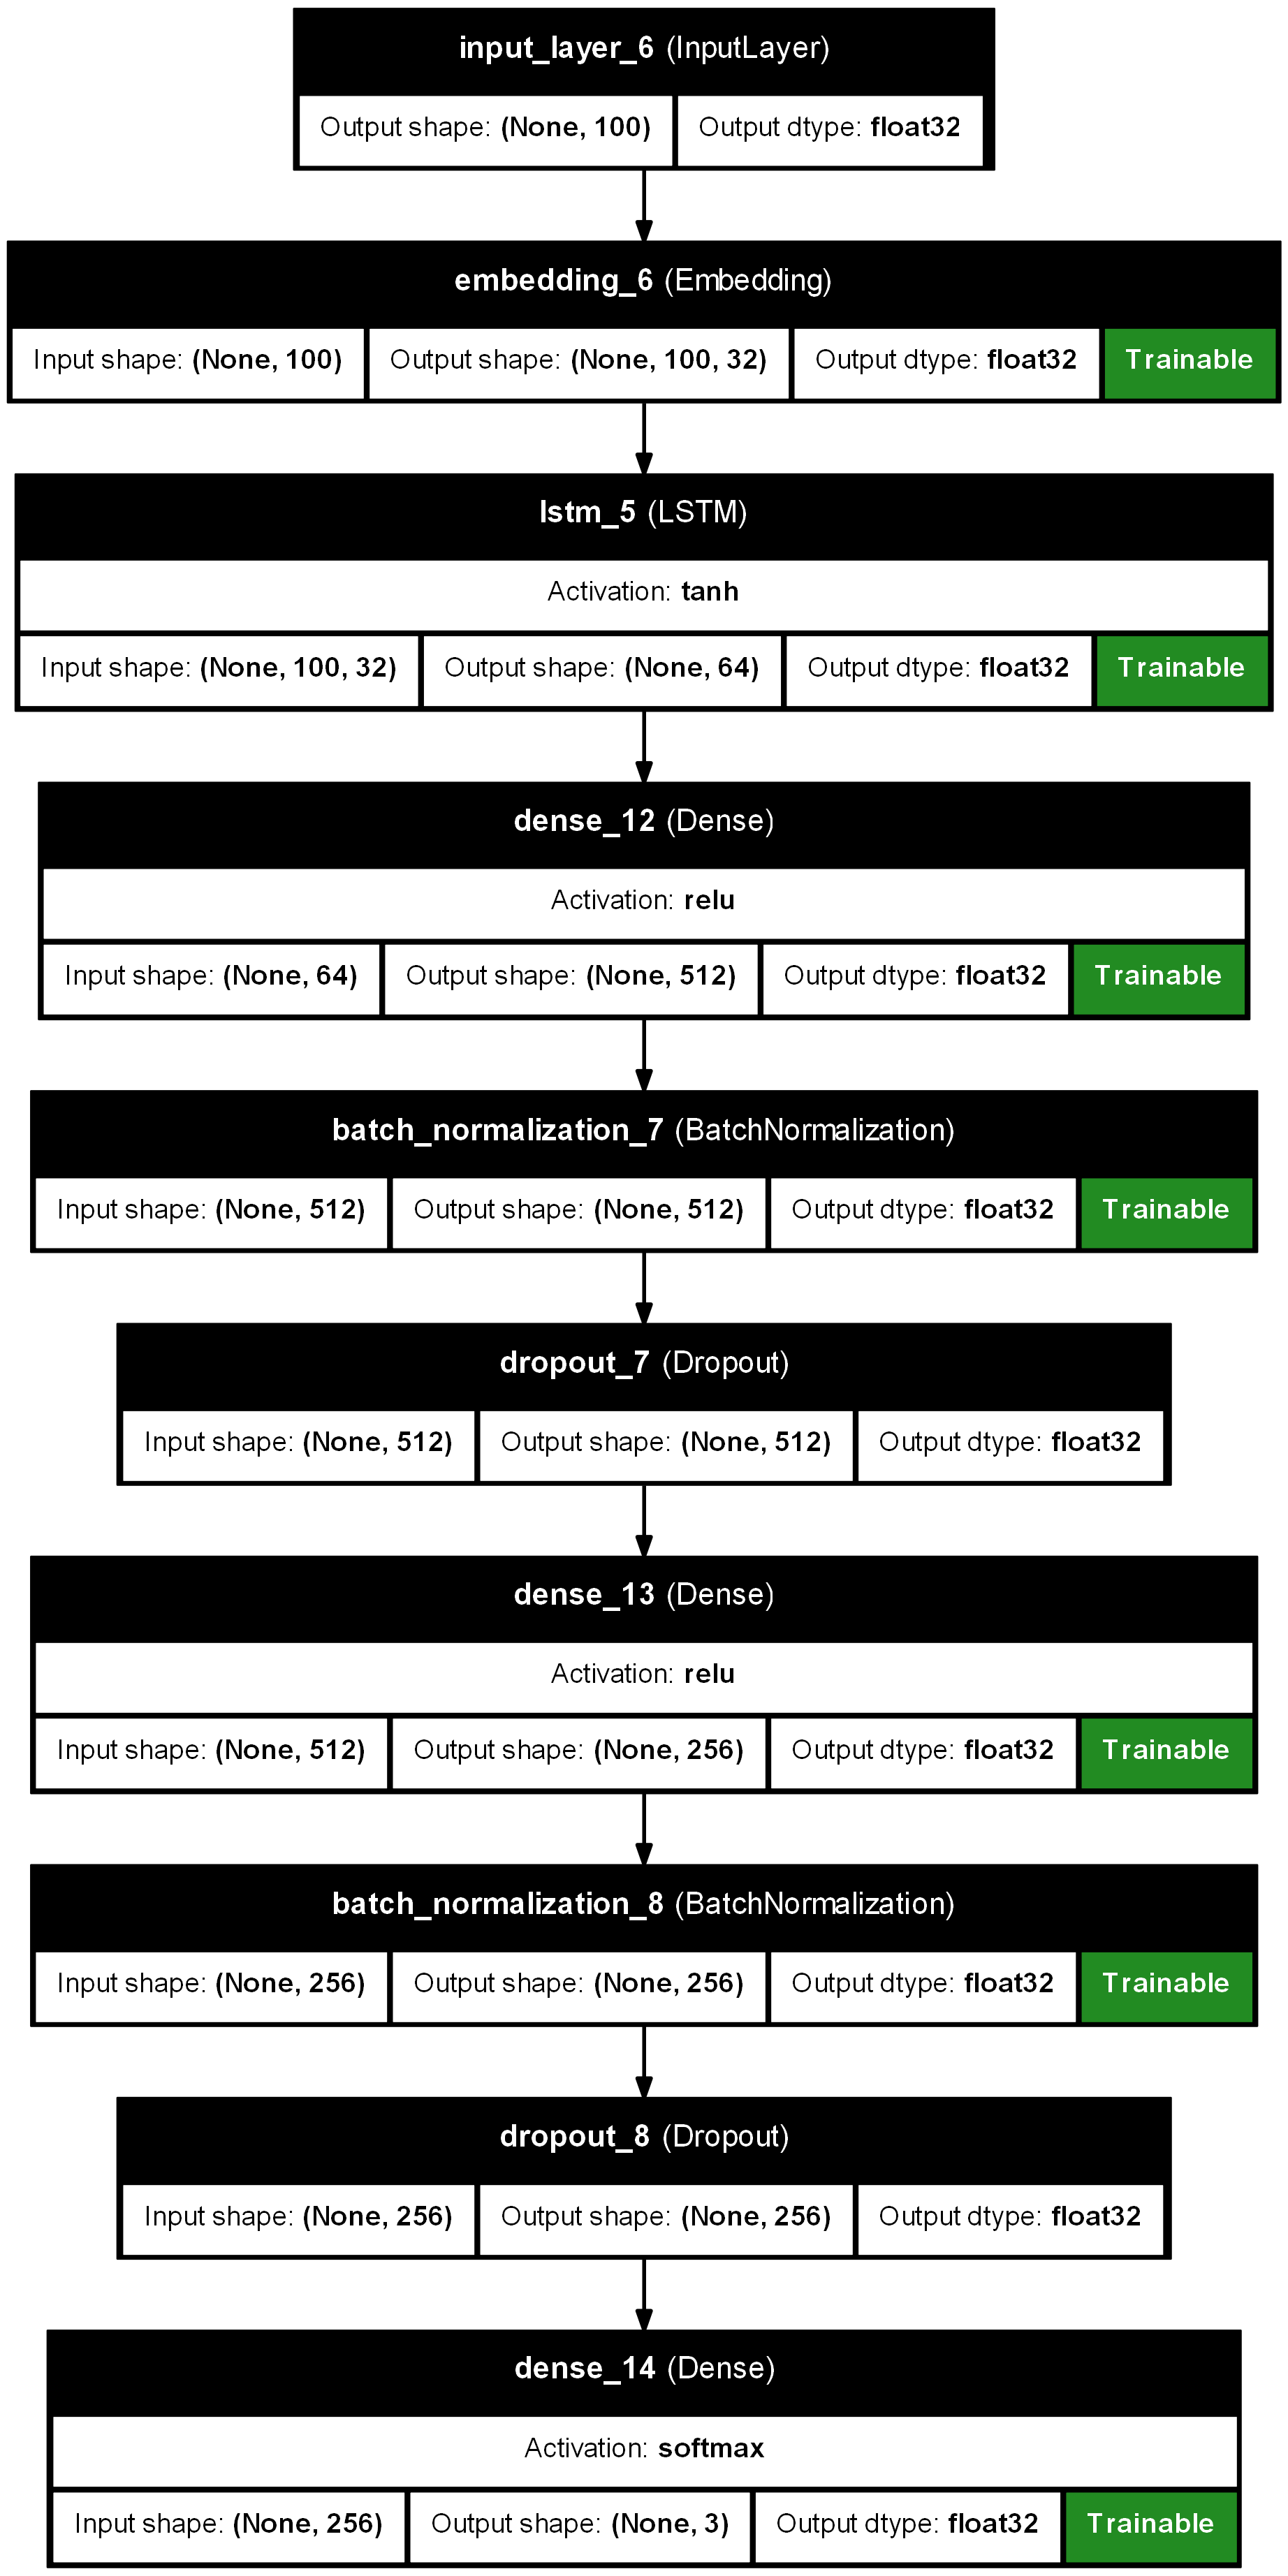

In [81]:
utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    show_layer_activations=True,
    show_trainable=True
)

#### Compile Model

In [99]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [100]:
model.compile(
    loss='SparseCategoricalCrossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

#### Train Model

In [101]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [102]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=0
)

In [103]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=128,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - accuracy: 0.7278 - loss: 0.7380 - val_accuracy: 0.7726 - val_loss: 0.5587 - learning_rate: 0.0010
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - accuracy: 0.9024 - loss: 0.2685 - val_accuracy: 0.8733 - val_loss: 0.3784 - learning_rate: 0.0010
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 29s 109ms/step - accuracy: 0.9320 - loss: 0.1886 - val_accuracy: 0.8388 - val_loss: 0.4951 - learning_rate: 0.0010
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - accuracy: 0.9447 - loss: 0.1529 - val_accuracy: 0.8745 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 29s 108ms/step - accuracy: 0.9552 - loss: 0.1292 - val_accuracy: 0.8707 - val_loss: 0.5086 - learning_rate: 0.0010
Epoch 6/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - accuracy: 0.9671 - loss: 0.0983 - val_accuracy: 0.8660 - val_loss: 0.5262 - learning_rate: 1.0000e-04
Epoch 7/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 27s 102ms/step - accuracy:

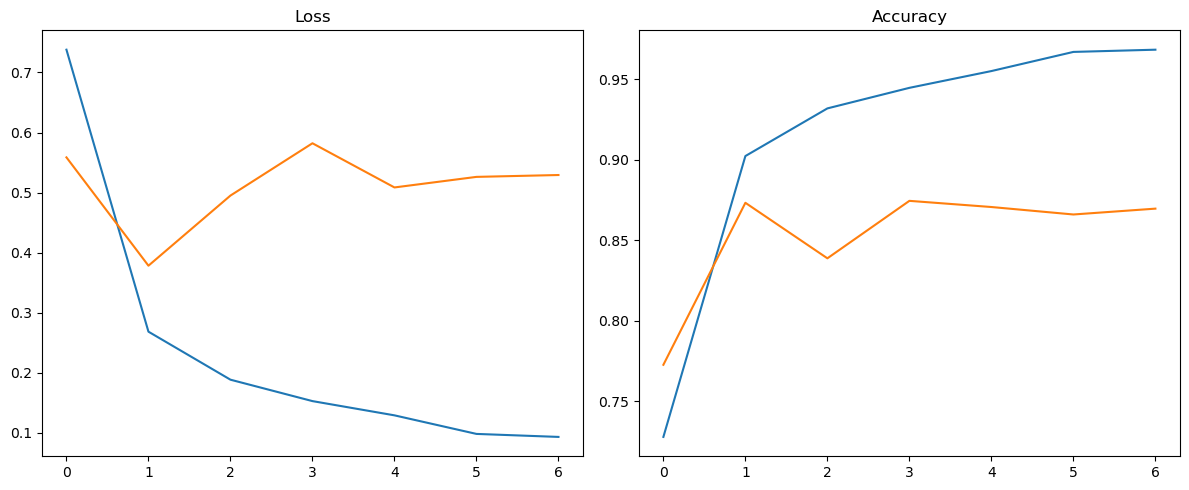

In [109]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(history.history['loss'])
sns.lineplot(history.history['val_loss'])
plt.title('Loss')
plt.subplot(1, 2, 2)
sns.lineplot(history.history['accuracy'])
sns.lineplot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.tight_layout()

#### Evaluate Model

In [110]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Validation Accuracy: {test_acc:.2f}, Validation Loss: {test_loss:.2f}")

155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8733 - loss: 0.3784
Validation Accuracy: 0.87, Validation Loss: 0.38


In [111]:
y_pred = model.predict(X_test)

155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


In [117]:
y_pred = y_pred.argmax(axis=1)

In [121]:
confusion_matrix = metrics.confusion_matrix(y_test.values, y_pred)

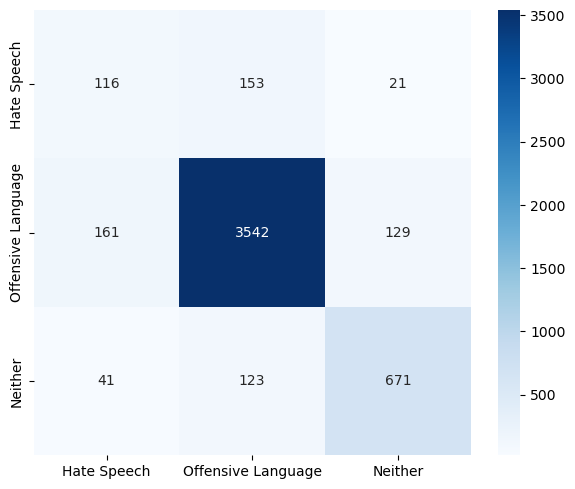

In [126]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=typ_list,
    yticklabels=typ_list
)
plt.tight_layout()